In [1]:
from llrf_app.app import LLRFApp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal
import time

plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

In [2]:
def calc_ps(wfm, title='', fullscale=32767, fs_mhz=115):
    fsdb = 20 * np.log10(fullscale / np.sqrt(2))
    f, pxx = signal.periodogram(
        wfm, fs_mhz, 'flattop', scaling='spectrum', nfft=8192)
    psd_dbfs = 10 * np.log10(pxx) - fsdb
    return f, psd_dbfs

def plot_ps(f, psd_dbfs, title='', annotate=False):
    fig, ax = plt.subplots()
    ax.set_xlabel('Freq [MHz]')
    ax.set_ylabel('Mag [dBFS]')
    ax.set_ylim(-120, 0)
    ax.set_title(title)
    if len(psd_dbfs.shape) == 1:
        ax.plot(f, psd_dbfs)
        if annotate:
            idx = np.argmax(psd_dbfs)
            pwr = psd_dbfs[idx]
            ax.annotate(
                f'{f[idx]:5.3f}  MHz\n {pwr:5.3f} dBFS',
                xy=(f[idx], pwr), xytext=(1, -20),
                arrowprops=dict(shrink=0.05))
    elif len(psd_dbfs.shape) == 2:   # plot psd array
        for ix, p in enumerate(psd_dbfs):
            ax.plot(f, p, label='adc' + str(ix))
        ax.legend()

# Read Board Support info

In [ ]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='LEMP', chan_keep=1)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :    -20.3 mV
  Power      :     22.8 mW
  Vbus       :     11.9 V
  Current    :  -1033.4 mA
INA219 U17, FMC1:
  Vshunt     :    -19.6 mV
  Power      :     64.6 mW
  Vbus       :     11.8 V
  Current    :    213.0 mA
INA219 U32, FMC2:
  Vshunt     :    -20.8 mV
  Power      :     25.5 mW
  Vbus       :     11.9 V
  Current    :    144.4 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01001111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
QSFP 2 is present:
  Vendor     :    AVAGO           
  Part       :    AFBR-79EQDZ     
  Serial     :    QH3201VZ        
  TXRX_LOS   :    11111101
  Temp       :    46 C
  Volt       :    3260 mV
  TxBias0    :    0 uA
  TxPwr0     :    0 uW
  RxPwr0     :    0 uW
  TxBias1    :    0 uA
  TxPwr1     :    0 uW
  RxPwr1     :    703 uW
  TxBias2    :    0 uA
  TxPwr2     :    

Measure a snapshot of RF amplitude and phases

In [4]:
def get_rfmon(llrf):
    index = [f'ADC{ch}' for ch in range(8)] + ['DAC0', 'DAC1']
    cols = ['mon_amp', 'mon_phs']
    df = pd.DataFrame(
        data=np.array(llrf.reg_read(cols)).T[:len(index)],
        index=index, columns=cols)
    df['Phase [deg]'] = df['mon_phs'] * 360 / (1 << 17)
    return df

def align_mo_phase(llrf):
    mo_adc_chan = llrf.read_reg('mo_adc_chan')
    llrf.write_reg('dds_phase_shift', 0)
    df_mon = llrf.get_rfmon()
    mo_phs = df_mon['Phase [deg]'].iloc[mo_adc_chan]
    llrf.write_reg('dds_phase_shift', -mo_phs / 360 * (1 << 19))

In [5]:
# align_mo_phase(llrf)  # this happens at boot time by CPU
df_mon = get_rfmon(llrf)
df_mon

,mon_amp,mon_phs,Phase [deg]
ADC0,2077,5299,14.554138
ADC1,1564,-7080,-19.445801
ADC2,2,36366,99.882202
ADC3,11835,20,0.054932
ADC4,2,-49138,-134.961548
ADC5,0,-65226,-179.148560
ADC6,2,-65226,-179.148560
ADC7,2,-32458,-89.148560
DAC0,6883,-5,-0.013733
DAC1,6883,-5,-0.013733


In [6]:
assert -0.1 < df_mon['Phase [deg]']['ADC3'] < 0.1

## Plot raw DAC / ADC data

In [7]:
llrf.reg_write([
    ('amp_setpoint', 60000),
    ('dac_permit', 1),
    ('pulse_mode', 0)
])
time.sleep(0.5)
adc_wfm = llrf.read_adc_bufs()
dac_wfm = llrf.read_dac_bufs()

In [7]:
df_dac = pd.DataFrame(dac_wfm.T, columns=[f'dac{n}' for n in range(2)])
df_dac['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
df_dac.set_index('Time [ns]', inplace=True)

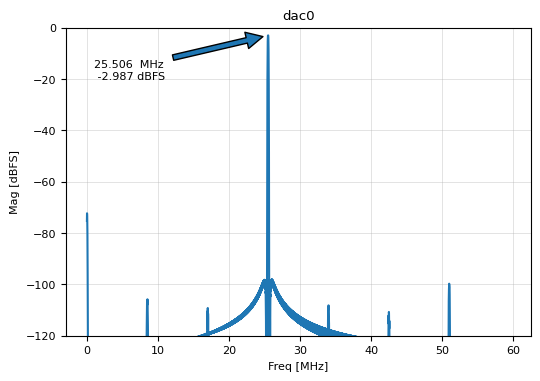

In [8]:
f, psd_dbfs = calc_ps(df_dac['dac0'], fs_mhz=1e3/llrf.dsp_clk_cycle)
plot_ps(f, psd_dbfs, title='dac0', annotate=True)

In [9]:
df = pd.DataFrame(adc_wfm.T, columns=[f'adc{n}' for n in range(8)])
df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
df.set_index('Time [ns]', inplace=True)

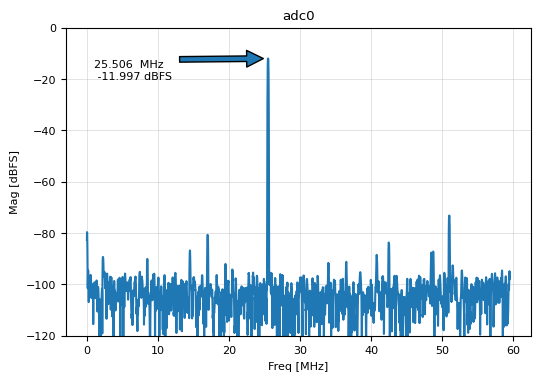

In [10]:
f, psd_dbfs = calc_ps(df['adc0'], fs_mhz=1e3/llrf.dsp_clk_cycle)
plot_ps(f, psd_dbfs, title='adc0', annotate=True)

## Plot circular buffer data (ADC0 only)

In [11]:
mp_traces = llrf.get_mp_wfm()

In [12]:
df_mp = pd.DataFrame(mp_traces.T, columns=['Amp [cnt]', 'Phase [deg]'])
df_mp['Time [ns]'] = np.arange(mp_traces.shape[-1]) * llrf.ts
df_mp.set_index('Time [ns]', inplace=True)

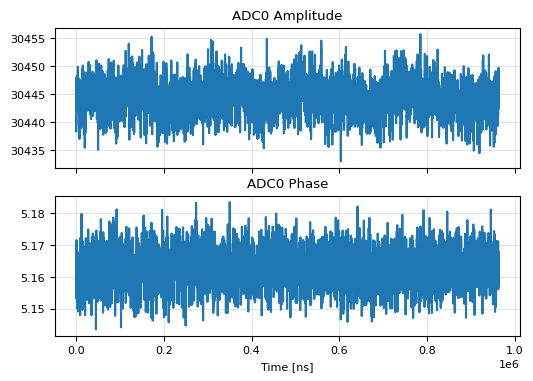

In [13]:
fig, axes = plt.subplots(2, sharex=True)
df_mp['Amp [cnt]'].plot(title='ADC0 Amplitude', ax=axes[0]);
df_mp['Phase [deg]'].plot(title='ADC0 Phase', ax=axes[1]);

# Pulse mode test

In [14]:
# generate 4µs pulse
pulse_high_len = int(4000 / llrf.dsp_clk_cycle  / llrf.cic_base_period)
llrf.reg_write([
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 16 counts


In [15]:
def read_raw_adcs():
    adc_wfm = llrf.read_adc_bufs()
    df = pd.DataFrame(adc_wfm.T, columns=[f'adc{n}' for n in range(8)])
    df['Time [ns]'] = np.arange(adc_wfm.shape[-1]) * llrf.dsp_clk_cycle
    df.set_index('Time [ns]', inplace=True)
    return df

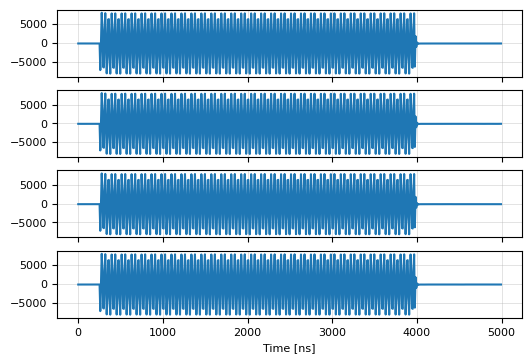

In [16]:
# read N times to check pulsing length certainty
N = 4
dfs = [read_raw_adcs()['adc0'] for _ in range(N)]

fig, axes = plt.subplots(N, sharex=True)
for df, ax in zip(dfs, axes):
    df.loc[:5000].plot(ax=ax);

# RAW ADC data demodulation demo

In [17]:
import sys
sys.path.append('../llrf_dsp/tests')
from llrf_dsp import DDC

In [18]:
ddc = DDC(num=3, den=14)
adc_data = read_raw_adcs()['adc0'].values
# ddc_data = ddc.calc_ddc_raw(adc_data)

Apply washout filter to raw data

In [19]:
# see fwashout.v
z, p, k = [1], [0, 15/16], 1
b, a = signal.zpk2tf(z, p, k)
adc_data1 = signal.lfilter(b, a, adc_data)
ddc_data = ddc.calc_ddc_raw(adc_data1)


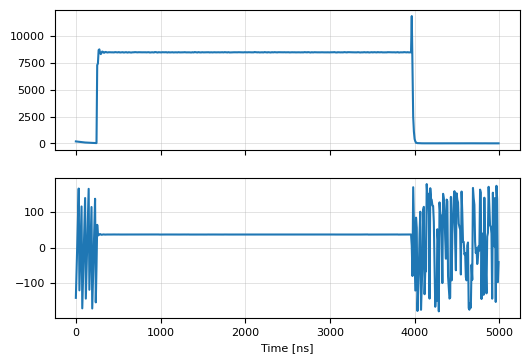

In [20]:
amp, phs = np.abs(ddc_data), np.angle(ddc_data, deg=True)

df = pd.DataFrame(np.array([amp, phs]).T, columns=['Amp [cnt]', 'Phase [deg]'])
df['Time [ns]'] = np.arange(ddc_data.shape[-1]) * llrf.dsp_clk_cycle
df.set_index('Time [ns]', inplace=True)
df = df.loc[:5000]
fig, axes = plt.subplots(2, sharex=True)
df['Amp [cnt]'].plot(ax=axes[0])
df['Phase [deg]'].plot(ax=axes[1]);

## Plot circular buffer data (ADC0 only)

In [21]:
mp_traces = llrf.get_mp_wfm()

In [22]:
df_mp = pd.DataFrame(mp_traces.T, columns=['Amp [cnt]', 'Phase [deg]'])
df_mp['Time [ns]'] = np.arange(mp_traces.shape[-1]) * llrf.ts
df_mp.set_index('Time [ns]', inplace=True)

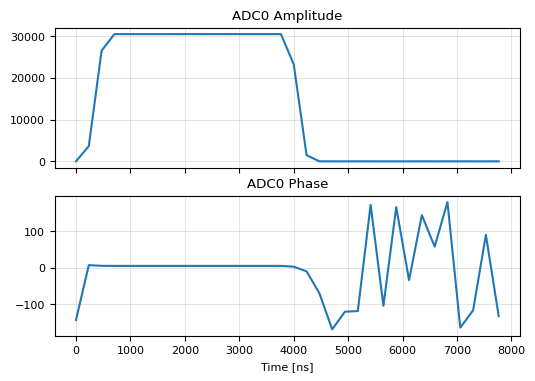

In [23]:
fig, axes = plt.subplots(2, sharex=True)
df_mp['Amp [cnt]'].loc[:8000].plot(title='ADC0 Amplitude', ax=axes[0]);
df_mp['Phase [deg]'].loc[:8000].plot(title='ADC0 Phase', ax=axes[1]);